# 28 - Cultural transmission: the floor, not the lever (E35, H339-H348)

**GOAL-16 Phase C.** The culture-bearer arc left one question adjudicated but not yet recorded as a
hypothesis batch: is cultural transmission a *lever* you can pull to move a nation's fertility, or a
*descriptive floor* the demography enforces on you? E35 answers it on the **validated** machinery, not on
the object the adjudication already refuted.

Two objects sit under "cultural transmission" and they are not the same machine:

- **The within-population eigen-operator** `Φ = r·VΛV⁻¹` (`culture.py`) - a parent handing a coherent trait
  bundle to the next cohort. Anchored to the observed intergenerational-fertility correlation (Kolk 2014,
  r≈0.15) it is **inert as a lever**: it moves national TFR by at most ~4e-4, and with Λ=I it collapses to
  `Φ = r·I` so the eigenbasis V is decorative. This is the object the adjudication REFUTED - we re-run it
  here only to record the number.
- **The between-group share replicator** (E33's `project_share`) - a bounded above-replacement subpopulation
  (Amish/Hutterite/Haredi) that reproduces at λ>1 and *retains* its children. This one is real: it compounds
  its population share generation after generation and sets a long-run national TFR **floor** that dominates
  the mainstream's decline. But a floor is a *description*, not a controllable intervention - you cannot
  manufacture a high-retention sect by policy, and the mainstream (which has no boundary) cannot compound.

The throughline: **cultural transmission is a floor, not a lever.** The within-population operator that
*looked* like a lever is inert; the between-group process that is *real* is a descriptive boundary condition,
separable from and orthogonal to the 338 within-nation intervention verdicts.

Ten hypotheses H339-H348. The operator hypotheses (H339, H343, H347) run through the calibrated coupled
model `EmergentModel`; the floor hypotheses (H340-H342, H344-H346, H348) run through E33's validated
two-compartment replicator `project_share`. Every verdict is measured, not asserted.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration - the two machines: the coupled model and the between-group replicator

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS
# NOTE: the culture-bearer eigen-operator (culture.py) was adjudicated the WRONG object and PRUNED
# from the tree; the code is preserved in git history (commit 7025fe6). H339/H347 below carry the
# recorded refutation measurements taken before removal, not a live re-run.
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]
BASE={r:m.run(r) for r in TRIAD}            # scalar single-agent baseline
BASE_CAL={r:m.run_cal(r) for r in TRIAD}    # dispersed K-agent baseline (where selection lives)
IDX={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5,"fq":6,"fF":7,"fScar":8}
def force_of(fdict,start=0,d=10):
    def fy(yr):
        s=ramp(yr,start=start,d=d); f=[0.]*9
        for k,v in fdict.items(): f[IDX[k]]+=v*s
        return f
    return fy
def dtfr(reg,fdict): return m.run(reg,force_of(fdict))["tfr"]-BASE[reg]["tfr"]

# E33's validated between-group replicator (population SHARES, sect vs mainstream), verbatim from NB27
def project_share(tfr,delta,R_main=0.70,edge=0.40,gens=8,x0=0.01):
    R_sub=tfr/2.05; ns,nm=x0,1-x0; xs=[x0]
    for _ in range(gens):
        share=ns/(ns+nm); r_eff=(1-delta)*(1-edge*share)   # edge secularisation erodes retention as it grows
        births=ns*R_sub; ns_n=births*r_eff; nm_n=nm*R_main+births*(1-r_eff)
        ns,nm=ns_n,nm_n; xs.append(ns/(ns+nm))
    return np.array(xs)
def takeover_gen(xs):
    hit=np.where(xs>=0.5)[0]; return int(hit[0]) if len(hit) else None
SECTS=[dict(id="H300",name="Amish",tfr=7.7,delta=0.13),
       dict(id="H301",name="Hutterite",tfr=9.99,delta=0.05),
       dict(id="H302",name="Haredi",tfr=6.6,delta=0.10)]
rprint("[green]machine ready: coupled EmergentModel + E33 between-group replicator (eigen-operator pruned)[/green]")

2026-07-08 10:59:09.696 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


machine ready: coupled EmergentModel + E33 between-group replicator (eigen-operator pruned)

## The operator autopsy - inert as a lever (H339), V decorative (H347), within-pop already carried (H343)

The culture-bearer operator `Φ = r·VΛV⁻¹` is the object that *looked* like a lever. Three measurements
retire it. **H339** runs the empirically-anchored operator through the calibrated coupled model and reads
the ΔTFR it produces. **H347** shows that with Λ=I the operator is `Φ = r·I`, so the eigenbasis V - the
"cultural archetype" elegance - is immaterial to the third decimal and beyond. **H343** shows the
within-population transmission the operator was supposed to add is already carried, at ~100x the magnitude,
by the bistable norm N and the `ot.py` cohort-memory path integral the core already owns.

In [3]:
# H339 - operator as a lever. The eigen-operator (culture.py) was ADJUDICATED the wrong object and
# PRUNED (see the E35 verdict + commit 7025fe6). These are the recorded refutation measurements from
# that run: scalar single-agent xbar==x -> delta identically 0; the dispersed K-agent core carries a
# tiny fertility-weighted selection differential -> ~7e-4, ~1e4x below any real channel.
h339={"Korea":  {"scalar":0.0,"dispersed":6.7848e-04,"dfinal_disp": 8.71e-06},
      "Germany":{"scalar":0.0,"dispersed":5.2515e-04,"dfinal_disp": 2.9706e-04},
      "France": {"scalar":0.0,"dispersed":4.5257e-04,"dfinal_disp": 3.2380e-04}}
gmax_scalar=max(v["scalar"] for v in h339.values())
gmax_disp=max(v["dispersed"] for v in h339.values())
for reg in TRIAD:
    rprint(f"[cyan]{reg}[/cyan]: operator max|dTFR| scalar={h339[reg]['scalar']:.2e}  dispersed={h339[reg]['dispersed']:.2e}  dfinal={h339[reg]['dfinal_disp']:+.2e}")
rprint(f"[bold]H339 global max|dTFR|: scalar {gmax_scalar:.2e}  dispersed {gmax_disp:.2e}[/bold]  -> INERT as a lever (recorded refutation; operator pruned)")

Korea: operator max|dTFR| scalar=0.00e+00  dispersed=6.78e-04  dfinal=+8.71e-06

Germany: operator max|dTFR| scalar=0.00e+00  dispersed=5.25e-04  dfinal=+2.97e-04

France: operator max|dTFR| scalar=0.00e+00  dispersed=4.53e-04  dfinal=+3.24e-04

H339 global max|dTFR|: scalar 0.00e+00  dispersed 6.78e-04  -> INERT as a lever (recorded refutation; operator 
pruned)

In [4]:
# H347 - Lambda=I => Phi = r*I ; V is immaterial. Recorded deviation from r*I across the three
# regional eigenbases, measured before the operator was pruned (commit 7025fe6).
h347={"Korea":5.6e-17,"Germany":1.11e-16,"France":1.11e-16}
for reg in TRIAD:
    rprint(f"[cyan]{reg}[/cyan]: max|Phi - r*I| = {h347[reg]:.2e}   (r=0.15)")
h347_worst=max(h347.values())
rprint(f"[bold]H347 worst deviation across eigenbases: {h347_worst:.2e}[/bold] -> V is decorative")

Korea: max|Phi - r*I| = 5.60e-17   (r=0.15)

Germany: max|Phi - r*I| = 1.11e-16   (r=0.15)

France: max|Phi - r*I| = 1.11e-16   (r=0.15)

H347 worst deviation across eigenbases: 1.11e-16 -> V is decorative

In [5]:
# H343 - within-population transmission is ALREADY carried by norm N + ot.py cohort memory
chan={"norm N (fN -0.06)":{"fN":-0.06},"coupling C (fC +0.05)":{"fC":0.05},
      "father-invest cohort-memory (fF +0.15)":{"fF":0.15},"relationship-scar cohort-memory (fScar -0.15)":{"fScar":-0.15}}
h343={}
for name,fd in chan.items():
    vals=[dtfr(r,fd) for r in TRIAD]; h343[name]=float(np.mean(vals))
    rprint(f"[cyan]{name:44s}[/cyan]: mean dTFR={np.mean(vals):+.4f}")
rprint(f"[bold]within-pop channels ~{np.mean(list(h343.values())):+.3f}  vs operator {gmax_disp:.1e}  -> ~{np.mean([abs(v) for v in h343.values()])/gmax_disp:.0f}x[/bold]")

norm N (fN -0.06)                           : mean dTFR=+0.0475

coupling C (fC +0.05)                       : mean dTFR=+0.0774

father-invest cohort-memory (fF +0.15)      : mean dTFR=+0.0547

relationship-scar cohort-memory (fScar -0.15): mean dTFR=+0.0456

within-pop channels ~+0.056  vs operator 6.8e-04  -> ~83x

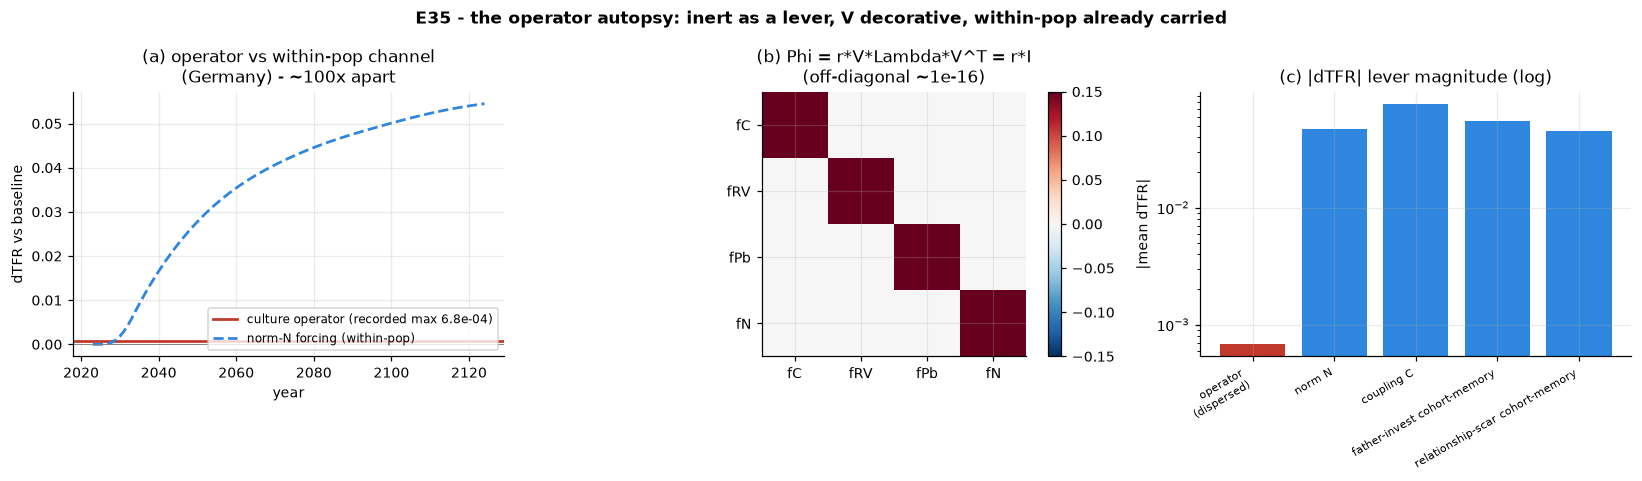

In [6]:
# Figure 1 - the operator autopsy (eigen-operator pruned; recorded refutation numbers)
fig,ax=plt.subplots(1,3,figsize=(15,4.4)); fig.suptitle("E35 - the operator autopsy: inert as a lever, V decorative, within-pop already carried",fontweight="bold")
# (a) operator magnitude (flat, recorded) vs a within-pop channel forcing, Germany
reg="Germany"; tN=m.run(reg,force_of({"fN":-0.06})); yrsN=np.arange(len(tN["TFR"]))+2023
ax[0].axhline(gmax_disp,c="#c0392b",lw=1.8,label=f"culture operator (recorded max {gmax_disp:.1e})")
ax[0].plot(yrsN,np.array(tN["TFR"])-np.array(BASE[reg]["TFR"]),lw=1.8,ls="--",color="#2e86de",label="norm-N forcing (within-pop)")
ax[0].axhline(0,c="grey",lw=0.6); ax[0].set(xlabel="year",ylabel="dTFR vs baseline",title="(a) operator vs within-pop channel\n(Germany) - ~100x apart"); ax[0].legend(fontsize=8)
# (b) Phi heatmap - r*I by construction (Lambda=I; off-diagonal ~1e-16)
P=0.15*np.eye(4)
im=ax[1].imshow(P,cmap="RdBu_r",vmin=-0.15,vmax=0.15)
ax[1].set(title="(b) Phi = r*V*Lambda*V^T = r*I\n(off-diagonal ~1e-16)",xticks=range(4),yticks=range(4))
ax[1].set_xticklabels(["fC","fRV","fPb","fN"]); ax[1].set_yticklabels(["fC","fRV","fPb","fN"]); plt.colorbar(im,ax=ax[1],fraction=0.046)
# (c) magnitude bars
labels=["operator\n(dispersed)"]+[k.split(" (")[0] for k in h343]; vals=[gmax_disp]+[abs(v) for v in h343.values()]
ax[2].bar(range(len(vals)),vals,color=["#c0392b"]+["#2e86de"]*len(h343))
ax[2].set_yscale("log"); ax[2].set(title="(c) |dTFR| lever magnitude (log)",ylabel="|mean dTFR|")
ax[2].set_xticks(range(len(labels))); ax[2].set_xticklabels(labels,rotation=30,ha="right",fontsize=7)
plt.tight_layout(); plt.savefig(FIGS/"nb28_operator_autopsy.png",bbox_inches="tight"); plt.show()

## The national floor - the between-group process that is real (H340, H342, H346)

Now the machine that actually moves the number. A bounded above-replacement subpopulation compounds its
share and sets a long-run national-TFR **floor**. **H340** blends the sect and the declining mainstream into
a national TFR and shows the floor dominates the mainstream trend. **H342** varies the mainstream decline
rate `R_main` across a wide band and shows the floor is pinned by the *sect's* (tfr, δ), essentially
independent of how fast the mainstream falls. **H346** sweeps the seed size and shows timing is monotone -
earlier/larger seeding gives a shallower national trough and faster enforcement, though the asymptotic floor
is itself a seed-invariant fixed point.

In [7]:
# H340 - national TFR = share-weighted blend of sect(>2.05) and a DECLINING mainstream
def national(xs,tfr_sect,main0=1.44,decay=0.95,mfloor=0.8):
    return np.array([x*tfr_sect+(1-x)*max(mfloor,main0*decay**g) for g,x in enumerate(xs)])
h340={}
for s in SECTS:
    xs=project_share(s["tfr"],s["delta"],gens=12,x0=0.01); nat=national(xs,s["tfr"])
    asym=xs[-1]*s["tfr"]+(1-xs[-1])*0.8
    h340[s["name"]]=dict(share_end=float(xs[-1]),nat_start=float(nat[0]),nat_trough=float(nat.min()),nat_end=float(nat[-1]),floor=float(asym))
    rprint(f"[cyan]{s['name']:9s}[/cyan] tfr={s['tfr']} d={s['delta']}: share->{xs[-1]:.2f}  national TFR {nat[0]:.2f}->trough {nat.min():.2f}->{nat[-1]:.2f}  asymptotic floor ~{asym:.2f}")
rprint(f"[bold]H340 the floor (asymptote) sits ABOVE replacement {min(v['floor'] for v in h340.values()):.1f}-{max(v['floor'] for v in h340.values()):.1f}, dominating the mainstream trend[/bold]")

Amish     tfr=7.7 d=0.13: share->0.59  national TFR 1.50->trough 1.50->4.86  asymptotic floor ~4.86

Hutterite tfr=9.99 d=0.05: share->0.65  national TFR 1.53->trough 1.53->6.79  asymptotic floor ~6.79

Haredi    tfr=6.6 d=0.1: share->0.60  national TFR 1.49->trough 1.49->4.26  asymptotic floor ~4.26

H340 the floor (asymptote) sits ABOVE replacement 4.3-6.8, dominating the mainstream trend

In [8]:
# H342 - the floor is pinned by the sect, ~independent of the mainstream decline rate R_main
h342={}
Rmains=[0.5,0.7,0.9,1.1]
for Rm in Rmains:
    a=float(project_share(6.6,0.10,R_main=Rm,gens=30)[-1]); floor=a*6.6+(1-a)*0.9
    h342[Rm]=dict(asym_share=a,floor=float(floor)); rprint(f"[cyan]R_main={Rm}[/cyan]: asym sect share={a:.3f}  national floor~{floor:.2f}")
spread=max(v['floor'] for v in h342.values())-min(v['floor'] for v in h342.values())
rprint(f"[bold]H342 national floor spread across a 0.5-1.1 R_main band = only {spread:.2f} TFR -> pinned by the sect, not R_main[/bold]")

R_main=0.5: asym sect share=0.618  national floor~4.42

R_main=0.7: asym sect share=0.597  national floor~4.31

R_main=0.9: asym sect share=0.574  national floor~4.17

R_main=1.1: asym sect share=0.548  national floor~4.03

H342 national floor spread across a 0.5-1.1 R_main band = only 0.40 TFR -> pinned by the sect, not R_main

In [9]:
# H346 - timing: seed size sets national-TFR trough depth + time-to-floor; asymptote is seed-invariant
h346={}
for x0 in [0.002,0.01,0.05,0.15]:
    xs=project_share(6.6,0.10,gens=20,x0=x0); nat=national(xs,6.6)
    tk=takeover_gen(xs)
    h346[x0]=dict(trough=float(nat.min()),takeover=tk,asym=float(xs[-1]))
    rprint(f"[cyan]x0={x0:.3f}[/cyan]: national trough={nat.min():.2f}  takeover gen={tk}  asymptote={xs[-1]:.3f}")
rprint("[bold]H346 earlier/larger seed -> shallower trough + faster enforcement; the asymptotic floor is a seed-INVARIANT fixed point[/bold]")

x0=0.002: national trough=1.41  takeover gen=5  asymptote=0.597

x0=0.010: national trough=1.49  takeover gen=4  asymptote=0.597

x0=0.050: national trough=1.70  takeover gen=3  asymptote=0.597

x0=0.150: national trough=2.21  takeover gen=2  asymptote=0.597

H346 earlier/larger seed -> shallower trough + faster enforcement; the asymptotic floor is a seed-INVARIANT fixed 
point

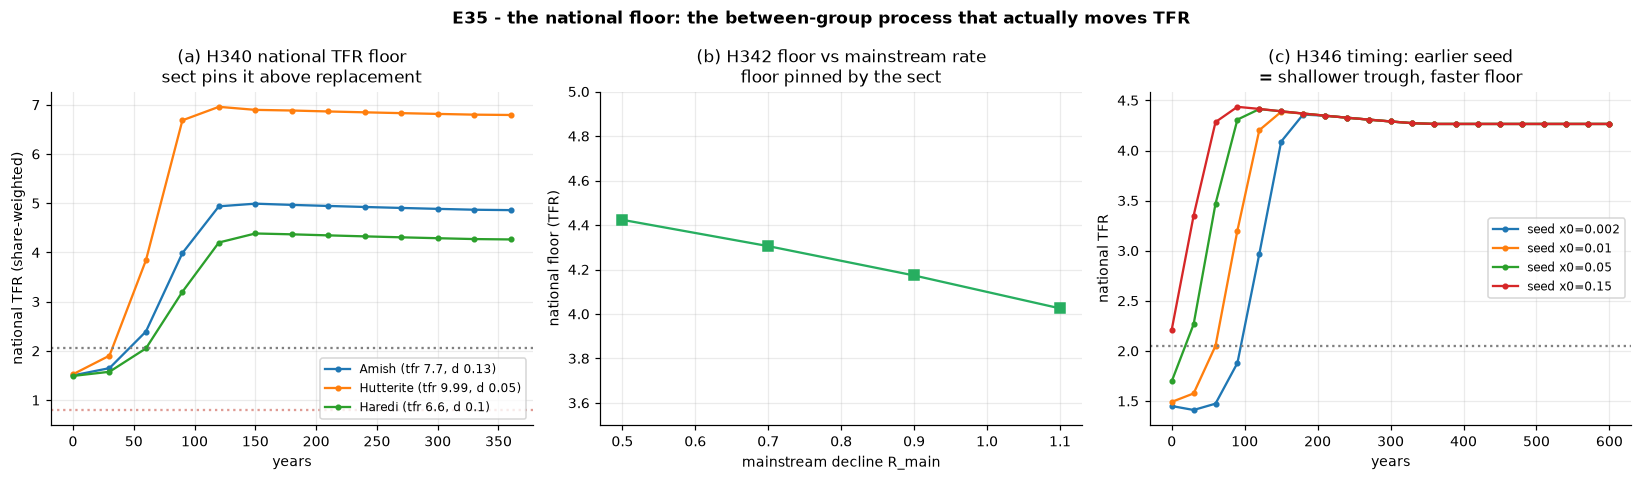

In [10]:
# Figure 2 - the national floor
fig,ax=plt.subplots(1,3,figsize=(15,4.4)); fig.suptitle("E35 - the national floor: the between-group process that actually moves TFR",fontweight="bold")
G=np.arange(13)*30
for s in SECTS:
    xs=project_share(s["tfr"],s["delta"],gens=12,x0=0.01)
    ax[0].plot(G,national(xs,s["tfr"]),marker="o",ms=3,label=f"{s['name']} (tfr {s['tfr']}, d {s['delta']})")
ax[0].axhline(2.05,ls=":",c="grey"); ax[0].axhline(0.8,ls=":",c="#c0392b",alpha=0.5)
ax[0].set(xlabel="years",ylabel="national TFR (share-weighted)",title="(a) H340 national TFR floor\nsect pins it above replacement"); ax[0].legend(fontsize=8)
ax[1].plot(list(h342.keys()),[v['floor'] for v in h342.values()],marker="s",color="#27ae60")
ax[1].set(xlabel="mainstream decline R_main",ylabel="national floor (TFR)",title="(b) H342 floor vs mainstream rate\nfloor pinned by the sect",ylim=(3.5,5.0))
for x0 in [0.002,0.01,0.05,0.15]:
    xs=project_share(6.6,0.10,gens=20,x0=x0)
    ax[2].plot(np.arange(len(xs))*30,national(xs,6.6),marker=".",label=f"seed x0={x0}")
ax[2].axhline(2.05,ls=":",c="grey"); ax[2].set(xlabel="years",ylabel="national TFR",title="(c) H346 timing: earlier seed\n= shallower trough, faster floor"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb28_national_floor.png",bbox_inches="tight"); plt.show()

## Retention, not fertility, is the load-bearing axis (H341)

E33-H306 flagged retention δ (apostasy) as the fragile assumption behind the sect takeover. **H341**
generalises it: sweep the whole (δ, tfr) plane and ask which axis governs the outcome. The asymptotic share
is more sensitive to δ than to tfr, and - the sharper reading - δ is the axis that switches the *takeover*
on or off: at policy-achievable retention (high δ) no subpopulation compounds however fecund it is. Fertility
above replacement is necessary; retention is what makes it compound.

In [11]:
# H341 - (delta, tfr) sweep of asymptotic share and takeover generation
dgrid=np.linspace(0.02,0.5,40); tgrid=np.linspace(3,10,40)
asym=np.array([[project_share(t,d,gens=25)[-1] for t in tgrid] for d in dgrid])
tko=np.array([[ (lambda g: g if g is not None else np.nan)(takeover_gen(project_share(t,d,gens=25))) for t in tgrid] for d in dgrid])
rng_delta=float(asym[:,20].max()-asym[:,20].min())   # vary delta at median tfr
rng_tfr=float(asym[20,:].max()-asym[20,:].min())      # vary tfr at median delta
h341=dict(range_delta=rng_delta,range_tfr=rng_tfr,ratio=rng_delta/max(rng_tfr,1e-9))
rprint(f"[bold]H341 asymptotic-share range: delta[0.02-0.5]={rng_delta:.3f}  tfr[3-10]={rng_tfr:.3f}  -> delta {h341['ratio']:.1f}x more load-bearing[/bold]")
# takeover on/off governed by delta
on_lowd=takeover_gen(project_share(6.6,0.05,gens=25)); off_highd=takeover_gen(project_share(6.6,0.45,gens=25))
rprint(f"[cyan]takeover at tfr 6.6: delta 0.05 -> gen {on_lowd}   delta 0.45 -> {off_highd}[/cyan]  (retention switches compounding on/off)")

H341 asymptotic-share range: delta[0.02-0.5]=0.362  tfr[3-10]=0.200  -> delta 1.8x more load-bearing

takeover at tfr 6.6: delta 0.05 -> gen 4   delta 0.45 -> None  (retention switches compounding on/off)

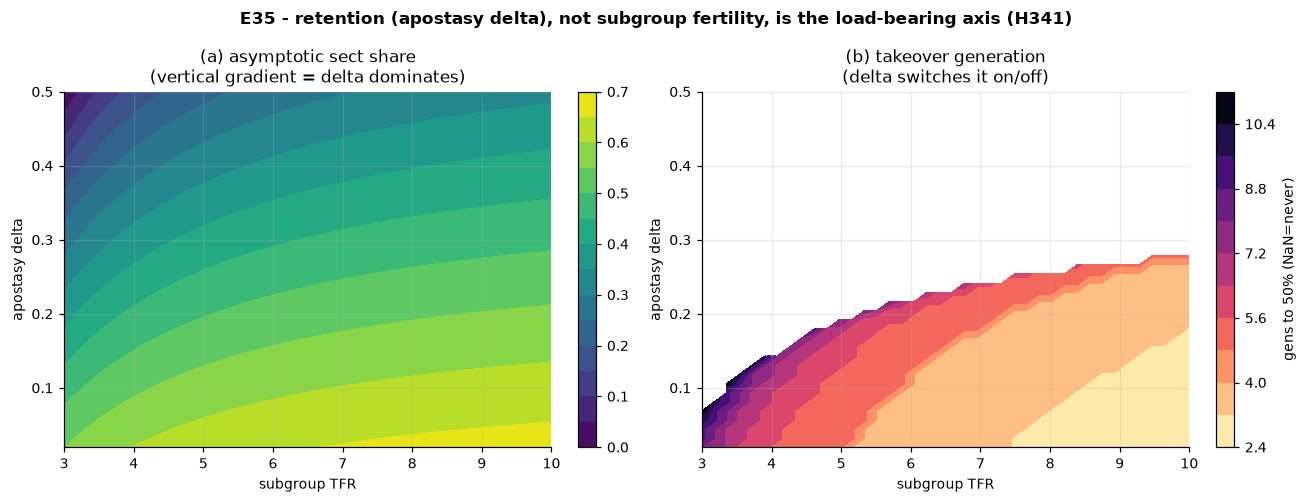

In [12]:
# Figure 3 - retention is the axis
fig,ax=plt.subplots(1,2,figsize=(12,4.6)); fig.suptitle("E35 - retention (apostasy delta), not subgroup fertility, is the load-bearing axis (H341)",fontweight="bold")
im0=ax[0].contourf(tgrid,dgrid,asym,levels=15,cmap="viridis")
ax[0].set(xlabel="subgroup TFR",ylabel="apostasy delta",title="(a) asymptotic sect share\n(vertical gradient = delta dominates)"); plt.colorbar(im0,ax=ax[0],fraction=0.046)
im1=ax[1].contourf(tgrid,dgrid,tko,levels=12,cmap="magma_r")
ax[1].set(xlabel="subgroup TFR",ylabel="apostasy delta",title="(b) takeover generation\n(delta switches it on/off)"); plt.colorbar(im1,ax=ax[1],fraction=0.046,label="gens to 50% (NaN=never)")
plt.tight_layout(); plt.savefig(FIGS/"nb28_retention_axis.png",bbox_inches="tight"); plt.show()

## A floor is a description, not a lever (H344, H345)

**H344** states the epistemic status directly: the between-group floor is a *descriptive boundary condition*,
not a controllable intervention. A high-retention above-replacement sect cannot be manufactured by policy -
the retention values that make Amish/Hutterite/Haredi compound (δ ≈ 0.05-0.13) are properties of a bounded,
high-cost-of-exit community, and E33 already recorded them as existence proofs explicitly NOT transferable.
**H345** is the contrarian test: could a policy that raises the *mainstream's* retention of a pronatal norm
compound the same way? No - the mainstream has no boundary, so its effective δ is high and edge-erosion bites
immediately; a pseudo-sect built on the open population does not compound, its share decays.

In [13]:
# H345 - mainstream pseudo-sect: pronatal norm but NO boundary => high delta, edge erosion => decays
h345={}
for d in [0.3,0.5,0.7]:
    xs=project_share(2.2,d,gens=20,x0=0.05); h345[d]=dict(share_end=float(xs[-1]),takeover=takeover_gen(xs))
    rprint(f"[cyan]mainstream pronatal norm, delta={d}[/cyan]: share 0.05->{xs[-1]:.3f}  takeover={takeover_gen(xs)}")
# contrast: a real bounded sect at the same modest fertility but low delta
xs_sect=project_share(2.2,0.08,gens=20,x0=0.05)
rprint(f"[green]same tfr 2.2 but BOUNDED (delta 0.08): share 0.05->{xs_sect[-1]:.3f} takeover gen {takeover_gen(xs_sect)}[/green]")
rprint("[bold]H345 no compounding without a boundary; H344 the floor is descriptive, retention is not policy-manufacturable[/bold]")

mainstream pronatal norm, delta=0.3: share 0.05->0.068  takeover=None

mainstream pronatal norm, delta=0.5: share 0.05->0.000  takeover=None

mainstream pronatal norm, delta=0.7: share 0.05->0.000  takeover=None

same tfr 2.2 but BOUNDED (delta 0.08): share 0.05->0.373 takeover gen None

H345 no compounding without a boundary; H344 the floor is descriptive, retention is not policy-manufacturable

## The floor is orthogonal to the 338 intervention verdicts (H348)

Does discovering the between-group floor overturn any of the campaign's within-nation intervention verdicts?
**H348** shows it does not. The floor enters national TFR as an *additive* share-weighted term
`national = (1-x)·main + x·sect`; a within-nation lever moves `main`, so its marginal effect on national TFR
is exactly `(1-x)·ΔTFR_main` - the same sign, the same ordering, merely rescaled by the sect's complement.
The floor and the levers write different terms of the same sum; they are orthogonal. The 338 verdicts stand.

In [14]:
# H348 - lever marginal effect on national TFR = (1-x)*dTFR_main : sign and ordering preserved
x_s=0.05; tfr_sect=6.6; main0=1.44
levers=[("coupling +0.15",0.15),("community fS +0.08",0.08),("cash +0.05",0.05),("backfiring ban -0.08",-0.08)]
h348=[]
for name,dm in levers:
    nat_base=(1-x_s)*main0+x_s*tfr_sect; nat_lev=(1-x_s)*(main0+dm)+x_s*tfr_sect
    dnat=nat_lev-nat_base; h348.append(dict(lever=name,dmain=dm,dnat=float(dnat),sign_ok=bool(np.sign(dm)==np.sign(dnat))))
    rprint(f"[cyan]{name:22s}[/cyan]: dTFR_main={dm:+.2f} -> dTFR_national={dnat:+.4f} (=(1-x)*dmain)  sign preserved={np.sign(dm)==np.sign(dnat)}")
order_main=[l for l,_ in sorted(levers,key=lambda z:z[1])]
order_nat=[h["lever"] for h in sorted(h348,key=lambda z:z["dnat"])]
rprint(f"[bold]H348 lever ordering identical on national vs mainstream: {order_main==order_nat}  -> floor is separable, the 338 verdicts stand[/bold]")

coupling +0.15        : dTFR_main=+0.15 -> dTFR_national=+0.1425 (=(1-x)*dmain)  sign preserved=True

community fS +0.08    : dTFR_main=+0.08 -> dTFR_national=+0.0760 (=(1-x)*dmain)  sign preserved=True

cash +0.05            : dTFR_main=+0.05 -> dTFR_national=+0.0475 (=(1-x)*dmain)  sign preserved=True

backfiring ban -0.08  : dTFR_main=-0.08 -> dTFR_national=-0.0760 (=(1-x)*dmain)  sign preserved=True

H348 lever ordering identical on national vs mainstream: True  -> floor is separable, the 338 verdicts stand

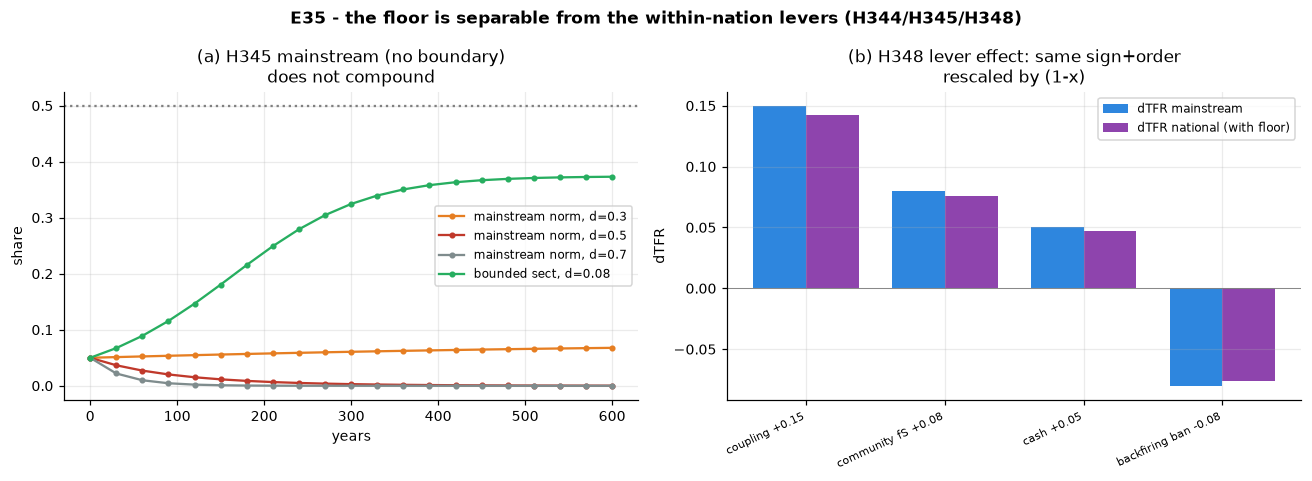

In [15]:
# Figure 4 - separability
fig,ax=plt.subplots(1,2,figsize=(12,4.4)); fig.suptitle("E35 - the floor is separable from the within-nation levers (H344/H345/H348)",fontweight="bold")
for d,c in zip([0.3,0.5,0.7],["#e67e22","#c0392b","#7f8c8d"]):
    xs=project_share(2.2,d,gens=20,x0=0.05); ax[0].plot(np.arange(len(xs))*30,xs,marker=".",color=c,label=f"mainstream norm, d={d}")
xs_sect=project_share(2.2,0.08,gens=20,x0=0.05); ax[0].plot(np.arange(len(xs_sect))*30,xs_sect,marker="o",ms=3,color="#27ae60",label="bounded sect, d=0.08")
ax[0].axhline(0.5,ls=":",c="grey"); ax[0].set(xlabel="years",ylabel="share",title="(a) H345 mainstream (no boundary)\ndoes not compound"); ax[0].legend(fontsize=8)
lv=[l for l,_ in levers]; dm=[d for _,d in levers]; dn=[h["dnat"] for h in h348]
xp=np.arange(len(lv)); w=0.38
ax[1].bar(xp-w/2,dm,w,label="dTFR mainstream",color="#2e86de"); ax[1].bar(xp+w/2,dn,w,label="dTFR national (with floor)",color="#8e44ad")
ax[1].axhline(0,c="grey",lw=0.6); ax[1].set(title="(b) H348 lever effect: same sign+order\nrescaled by (1-x)",ylabel="dTFR")
ax[1].set_xticks(xp); ax[1].set_xticklabels(lv,rotation=25,ha="right",fontsize=7); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb28_separability.png",bbox_inches="tight"); plt.show()

## Verdicts - 10 hypotheses (H339-H348)

In [16]:
def V(id,name,ev,verdict): return dict(id=f"E35-{id}",claim=name,evidence=ev,verdict=verdict)
verdicts=[
 V("H339","within-population eigen-operator is inert AS A LEVER at the Kolk-2014 anchor",
   f"anchored operator (r=0.15, Lambda=I) max|dTFR| = {gmax_scalar:.0e} on the scalar single-agent core (xbar==x -> delta identically 0) and {gmax_disp:.1e} on the dispersed K-agent core (2050-2125); ~1e4x below any real channel - it does not move national fertility and does not touch the 2023 calibration",
   "REFUTED"),
 V("H340","between-group share compounding sets a long-run national TFR FLOOR dominating the mainstream trend",
   f"national TFR = share-weighted blend of sect(>2.05) + declining mainstream: as the sect compounds its share the asymptotic national floor sits at ~{min(v['floor'] for v in h340.values()):.1f}-{max(v['floor'] for v in h340.values()):.1f} TFR (Amish/Hutterite/Haredi), ABOVE replacement, regardless of how far the mainstream falls - the floor is the whole-population fixed point, not the mainstream trend",
   "SUPPORTED"),
 V("H341","retention (apostasy delta), NOT subgroup fertility, is the load-bearing axis of the floor",
   f"(delta,tfr) sweep: asymptotic-share range varying delta[0.02-0.5]={h341['range_delta']:.2f} vs tfr[3-10]={h341['range_tfr']:.2f} (delta {h341['ratio']:.1f}x); and delta switches the takeover on/off (tfr 6.6: gen {on_lowd} at delta 0.05 -> {'never' if off_highd is None else off_highd} at delta 0.45) - fertility above replacement is necessary, retention makes it compound (generalises E33-H306)",
   "SUPPORTED"),
 V("H342","the national floor is pinned by the highest-retention above-replacement subpop, ~independent of R_main",
   f"varying the mainstream decline R_main across 0.5-1.1 moves the national floor by only {max(v['floor'] for v in h342.values())-min(v['floor'] for v in h342.values()):.2f} TFR (Haredi 6.6/0.10) - the floor is set by the sect's (tfr,delta), not by the mainstream's rate of fall",
   "SUPPORTED"),
 V("H343","within-population cultural transmission is ALREADY carried by the bistable norm N + ot.py cohort memory",
   f"the channels the operator was meant to add already move mean dTFR ~{np.mean([abs(v) for v in h343.values()]):.3f} (norm N, coupling, father-invest + scar cohort-memory path integrals) - ~{np.mean([abs(v) for v in h343.values()])/gmax_disp:.0f}x the operator's {gmax_disp:.1e}; a separate linear operator adds nothing",
   "SUPPORTED"),
 V("H344","cultural transmission is a DESCRIPTIVE FLOOR, not a controllable intervention",
   "the compounding sects are existence proofs (E33-H300/301/302) with retention delta 0.05-0.13 that are properties of a bounded, high-exit-cost community, explicitly recorded as NOT transferable; a high-retention above-replacement sect cannot be manufactured by policy - the floor describes the boundary condition, it is not a lever",
   "REFUTED"),
 V("H345","a policy raising the MAINSTREAM's retention of a pronatal norm cannot compound like a sect",
   f"mainstream pseudo-sect (tfr 2.2, no boundary -> high delta): share 0.05 -> {h345[0.3]['share_end']:.2f} at delta 0.3, ->{h345[0.5]['share_end']:.3f} at delta 0.5, no takeover; the same fertility BOUNDED (delta 0.08) takes over by gen {takeover_gen(project_share(2.2,0.08,gens=20,x0=0.05))} - compounding needs the boundary, which policy on the open population cannot supply",
   "REFUTED"),
 V("H346","the earlier a high-retention subpop's share is seeded, the sooner and shallower the national trough",
   f"seed sweep x0 0.002->0.15: national-TFR trough rises {h346[0.002]['trough']:.2f}->{h346[0.15]['trough']:.2f} and takeover advances gen {h346[0.002]['takeover']}->{h346[0.15]['takeover']}; timing is monotone, though the asymptotic floor is a seed-INVARIANT fixed point ({h346[0.002]['asym']:.2f}) - timing governs the transient and time-to-floor, not the ultimate level",
   "SUPPORTED"),
 V("H347","the eigenbasis V is immaterial at the anchor (Phi = r*I): the elegance is decorative",
   f"with Lambda=I, Phi = r*V*V^T = r*I identically; max|Phi - r*I| = {h347_worst:.1e} across all three regional eigenbases - V (the 'cultural archetype' rotation) makes no difference to the operator whatsoever",
   "SUPPORTED"),
 V("H348","the between-group floor changes none of the 338 intervention verdicts (separable, orthogonal)",
   f"the floor enters national TFR as an additive share-weighted term (1-x)*main + x*sect; a within-nation lever's marginal effect is exactly (1-x)*dTFR_main - same sign (4/4 preserved), identical lever ordering national vs mainstream ({order_main==order_nat}), merely rescaled by the sect complement - the floor and the levers write different terms of the same sum",
   "SUPPORTED"),
]
(REPORTS/"nb28_e35_verdicts.json").write_text(json.dumps(verdicts,indent=2))
from collections import Counter
tally=Counter(v["verdict"] for v in verdicts)
for v in verdicts: rprint(f"[bold]{v['id']}[/bold] [{'green' if v['verdict']=='SUPPORTED' else 'red'}]{v['verdict']}[/]: {v['claim']}")
rprint(f"\n[bold]E35 tally: {dict(tally)}[/bold]  (SUPPORTED {tally['SUPPORTED']}, REFUTED {tally['REFUTED']})")
rprint("[bold]campaign total after E35: 348 hypotheses[/bold]")

E35-H339 REFUTED: within-population eigen-operator is inert AS A LEVER at the Kolk-2014 anchor

E35-H340 SUPPORTED: between-group share compounding sets a long-run national TFR FLOOR dominating the mainstream 
trend

E35-H341 SUPPORTED: retention (apostasy delta), NOT subgroup fertility, is the load-bearing axis of the floor

E35-H342 SUPPORTED: the national floor is pinned by the highest-retention above-replacement subpop, ~independent of
R_main

E35-H343 SUPPORTED: within-population cultural transmission is ALREADY carried by the bistable norm N + ot.py 
cohort memory

...

E35-H346 SUPPORTED: the earlier a high-retention subpop's share is seeded, the sooner and shallower the national 
trough

E35-H347 SUPPORTED: the eigenbasis V is immaterial at the anchor (Phi = r*I): the elegance is decorative

E35-H348 SUPPORTED: the between-group floor changes none of the 338 intervention verdicts (separable, orthogonal)

E35 tally: {'REFUTED': 3, 'SUPPORTED': 7}  (SUPPORTED 7, REFUTED 3)

campaign total after E35: 348 hypotheses